In [ ]:

# ▶ Import all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import pickle
import warnings
warnings.filterwarnings('ignore')

import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, roc_curve, auc)

nltk.download('stopwords', quiet=True)

print('✅ All imports successful!')

In [ ]:

# ▶ Load combined dataset from Step 1
df = pd.read_csv('combined_news.csv')
print(f'Dataset loaded: {df.shape}')
print(df['label'].value_counts())


Dataset loaded: (44898, 6)
label
0    23481
1    21417
Name: count, dtype: int64


In [ ]:
# ▶ TEXT PREPROCESSING
# We combine title + text for better context, then clean it

stemmer = PorterStemmer()
stop_words = set(stopwords.words('english'))

def clean_text(text):
    """Clean and preprocess a single article's text."""
    # Convert to string (handle any NaN edge cases)
    text = str(text)

    # Step 1: Lowercase everything
    text = text.lower()

    # Step 2: Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # Step 3: Remove punctuation and numbers
    text = re.sub(r'[^a-z\s]', '', text)

    # Step 4: Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    # Step 5: Remove stopwords and apply stemming
    words = text.split()
    words = [stemmer.stem(w) for w in words if w not in stop_words and len(w) > 2]

    return ' '.join(words)

# Combine title and text, then clean
print('⏳ Cleaning text... (this takes ~1-2 minutes)')
df['combined_text'] = df['title'].fillna('') + ' ' + df['text'].fillna('')
df['cleaned_text'] = df['combined_text'].apply(clean_text)
print('✅ Text cleaning complete!')

# Show before and after example
print('\n--- BEFORE CLEANING ---')
print(df['combined_text'].iloc[0][:200])
print('\n--- AFTER CLEANING ---')
print(df['cleaned_text'].iloc[0][:200])


⏳ Cleaning text... (this takes ~1-2 minutes)
✅ Text cleaning complete!

--- BEFORE CLEANING ---
Ben Stein Calls Out 9th Circuit Court: Committed a ‘Coup d’état’ Against the Constitution 21st Century Wire says Ben Stein, reputable professor from, Pepperdine University (also of some Hollywood fame

--- AFTER CLEANING ---
ben stein call circuit court commit coup dtat constitut centuri wire say ben stein reput professor pepperdin univers also hollywood fame appear show film ferri bueller day made provoc statement judg j


In [ ]:

# ▶ Remove any empty rows after cleaning
df = df[df['cleaned_text'].str.strip() != '']
df = df.reset_index(drop=True)
print(f'Dataset after removing empty rows: {df.shape}')

Dataset after removing empty rows: (44889, 8)


In [ ]:

# ▶ TRAIN/TEST SPLIT (80% training, 20% testing)
X = df['cleaned_text']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f'Training samples : {len(X_train)}')
print(f'Testing samples  : {len(X_test)}')
print(f'\nTraining label distribution:')
print(y_train.value_counts())

Training samples : 35911
Testing samples  : 8978

Training label distribution:
label
0    18777
1    17134
Name: count, dtype: int64


In [ ]:

# ▶ TF-IDF VECTORIZATION
# Converts text into numerical features that ML models can understand
# max_features=50000 means we use the top 50,000 most important words

tfidf = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1, 2),   # Unigrams + bigrams (single words and word pairs)
    min_df=2              # Ignore words that appear in fewer than 2 documents
)

print('⏳ Fitting TF-IDF vectorizer...')
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)   # Note: only transform (not fit) on test data!

print(f'✅ TF-IDF complete!')
print(f'Feature matrix shape (training): {X_train_tfidf.shape}')
print(f'Feature matrix shape (testing) : {X_test_tfidf.shape}')


⏳ Fitting TF-IDF vectorizer...
✅ TF-IDF complete!
Feature matrix shape (training): (35911, 50000)
Feature matrix shape (testing) : (8978, 50000)


In [ ]:

# ▶ MODEL 1: LOGISTIC REGRESSION
print('⏳ Training Logistic Regression...')
lr_model = LogisticRegression(max_iter=1000, random_state=42, C=1.0)
lr_model.fit(X_train_tfidf, y_train)

lr_predictions = lr_model.predict(X_test_tfidf)
lr_accuracy = accuracy_score(y_test, lr_predictions)

print(f'\n✅ Logistic Regression Results:')
print(f'Accuracy: {lr_accuracy * 100:.2f}%')
print('\nDetailed Report:')
print(classification_report(y_test, lr_predictions,
                             target_names=['Fake News', 'Real News']))

⏳ Training Logistic Regression...

✅ Logistic Regression Results:
Accuracy: 98.67%

Detailed Report:
              precision    recall  f1-score   support

   Fake News       0.99      0.98      0.99      4695
   Real News       0.98      0.99      0.99      4283

    accuracy                           0.99      8978
   macro avg       0.99      0.99      0.99      8978
weighted avg       0.99      0.99      0.99      8978



In [ ]:

# ▶ MODEL 2: NAIVE BAYES
print('⏳ Training Naive Bayes...')
nb_model = MultinomialNB(alpha=0.1)
nb_model.fit(X_train_tfidf, y_train)

nb_predictions = nb_model.predict(X_test_tfidf)
nb_accuracy = accuracy_score(y_test, nb_predictions)

print(f'\n✅ Naive Bayes Results:')
print(f'Accuracy: {nb_accuracy * 100:.2f}%')
print('\nDetailed Report:')
print(classification_report(y_test, nb_predictions,
                             target_names=['Fake News', 'Real News']))

⏳ Training Naive Bayes...

✅ Naive Bayes Results:
Accuracy: 95.90%

Detailed Report:
              precision    recall  f1-score   support

   Fake News       0.96      0.96      0.96      4695
   Real News       0.96      0.96      0.96      4283

    accuracy                           0.96      8978
   macro avg       0.96      0.96      0.96      8978
weighted avg       0.96      0.96      0.96      8978



In [ ]:

# ▶ MODEL COMPARISON
print('=== MODEL COMPARISON ===')
print(f'Logistic Regression Accuracy : {lr_accuracy * 100:.2f}%')
print(f'Naive Bayes Accuracy         : {nb_accuracy * 100:.2f}%')

# Select the best model
if lr_accuracy >= nb_accuracy:
    best_model = lr_model
    best_predictions = lr_predictions
    best_name = 'Logistic Regression'
else:
    best_model = nb_model
    best_predictions = nb_predictions
    best_name = 'Naive Bayes'

print(f'\n🏆 Best Model: {best_name}')

=== MODEL COMPARISON ===
Logistic Regression Accuracy : 98.67%
Naive Bayes Accuracy         : 95.90%

🏆 Best Model: Logistic Regression


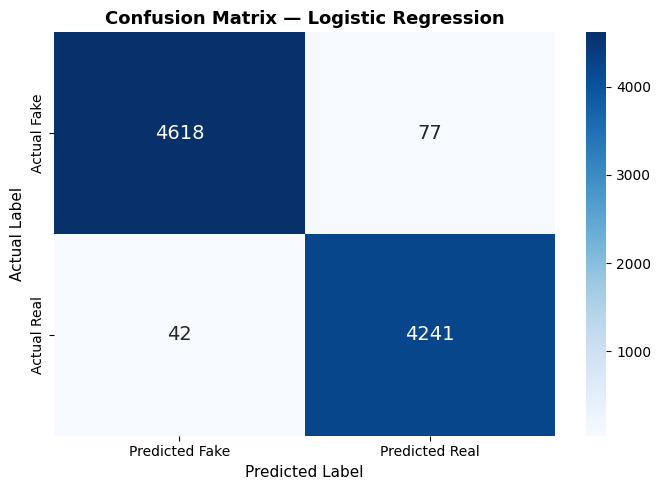

📊 Saved as confusion_matrix.png


In [ ]:
# ▶ VISUALIZATION 1: Confusion Matrix
cm = confusion_matrix(y_test, best_predictions)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Fake', 'Predicted Real'],
            yticklabels=['Actual Fake', 'Actual Real'],
            annot_kws={'size': 14})
plt.title(f'Confusion Matrix — {best_name}', fontsize=13, fontweight='bold')
plt.ylabel('Actual Label', fontsize=11)
plt.xlabel('Predicted Label', fontsize=11)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()
print('📊 Saved as confusion_matrix.png')

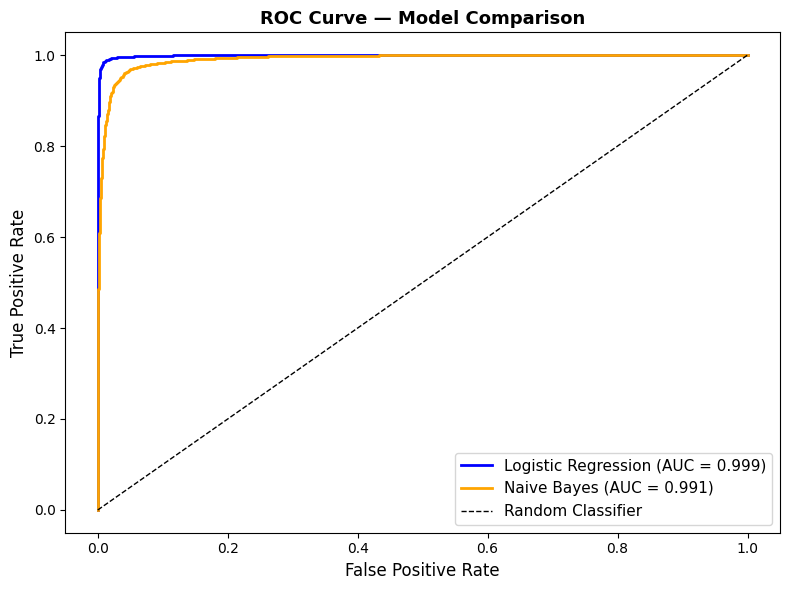

📊 Saved as roc_curve.png


In [ ]:

# ▶ VISUALIZATION 2: ROC Curve
lr_probs = lr_model.predict_proba(X_test_tfidf)[:, 1]
nb_probs = nb_model.predict_proba(X_test_tfidf)[:, 1]

fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_probs)
fpr_nb, tpr_nb, _ = roc_curve(y_test, nb_probs)
auc_lr = auc(fpr_lr, tpr_lr)
auc_nb = auc(fpr_nb, tpr_nb)

plt.figure(figsize=(8, 6))
plt.plot(fpr_lr, tpr_lr, color='blue', lw=2,
         label=f'Logistic Regression (AUC = {auc_lr:.3f})')
plt.plot(fpr_nb, tpr_nb, color='orange', lw=2,
         label=f'Naive Bayes (AUC = {auc_nb:.3f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve — Model Comparison', fontsize=13, fontweight='bold')
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150)
plt.show()
print('📊 Saved as roc_curve.png')


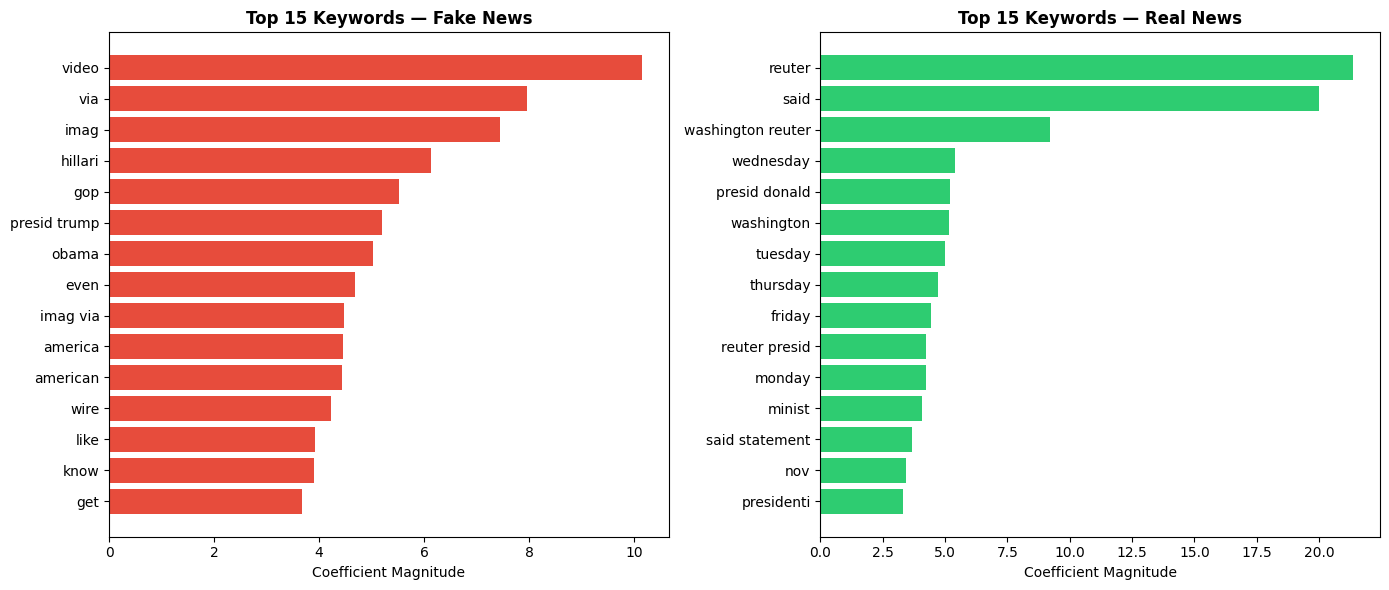

📊 Saved as top_keywords.png


In [ ]:

# ▶ VISUALIZATION 3: Top Keywords — Fake vs Real News
# Get top TF-IDF features for each class
feature_names = tfidf.get_feature_names_out()

# For Logistic Regression: positive coefficients = real, negative = fake
coefs = lr_model.coef_[0]
top_fake_idx = np.argsort(coefs)[:15]       # Most negative = most fake
top_real_idx = np.argsort(coefs)[-15:][::-1]  # Most positive = most real

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Fake news keywords
axes[0].barh(feature_names[top_fake_idx], np.abs(coefs[top_fake_idx]),
             color='#e74c3c')
axes[0].set_title('Top 15 Keywords — Fake News', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Coefficient Magnitude')
axes[0].invert_yaxis()

# Real news keywords
axes[1].barh(feature_names[top_real_idx], coefs[top_real_idx],
             color='#2ecc71')
axes[1].set_title('Top 15 Keywords — Real News', fontweight='bold', fontsize=12)
axes[1].set_xlabel('Coefficient Magnitude')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('top_keywords.png', dpi=150)
plt.show()
print('📊 Saved as top_keywords.png')


In [ ]:

# ▶ SAVE THE MODEL AND VECTORIZER
# We save both so the Streamlit app can load them without retraining

with open('model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

with open('tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

print('✅ Model saved as model.pkl')
print('✅ Vectorizer saved as tfidf_vectorizer.pkl')
print(f'\nFinal Model: {best_name}')
print(f'Final Accuracy: {max(lr_accuracy, nb_accuracy) * 100:.2f}%')
print('\n🎉 Step 2 Complete! Move on to Step3_Prediction_Test.ipynb')

✅ Model saved as model.pkl
✅ Vectorizer saved as tfidf_vectorizer.pkl

Final Model: Logistic Regression
Final Accuracy: 98.67%

🎉 Step 2 Complete! Move on to Step3_Prediction_Test.ipynb
